# Final Summary: DESI-HATS Crossmatch Project

This notebook summarizes each part of the project:
- The HATSification of the DESI DR1 Main Dark catalog
- Each of the crossmatches performed with the HATSified DESI catalog:
  - DESI x Gaia
  - DESI x LSST DP1 object
  - DESI x LSST DP2 dia_object
  - DESI (DR1) x DESI Legacy
  - DESI x LSST DP2 object
  - DESI x LSST DP2 dia_object

We summarize key metrics, including match counts, size on disk, partitions, and approximate coverate of sky.

In addition, we plot the magnitude distribution of the DESI x LSST DP2 object crossmatch, to confirm the overall quality of the matches. 

In [34]:
import logging
import warnings
from pathlib import Path

import hats
import lsdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dask.distributed import Client


pd.set_option('display.float_format', lambda x: '{:,.1f}'.format(x))

## 1. HATSifying the DESI DR1 Main Dark catalog

Initial DESI Main Dark catalog was stored in a series of FITS files, organized in directory trees based on healpix groups.

The total wall time taken to convert the catalog to HATS format was: **64m 26s**

HATS-format DESI Main Dark catalog:
| Catalog | Row Count | Size on Disk | Partitions | Approx. Coverage | Location |
|---------|-------------|--------------|------------|------------------|----------|
| DESI DR1 Main Dark catalog | 12_778_525 | 700GiB | 5_769 | 33.39% | `/global/cfs/cdirs/cosmo/www/users/olynn/` |


### 1.1 HATSified DESI Column Statistics

In [1]:
desi_cat = hats.read_hats("https://portal.nersc.gov/project/cosmo/users/olynn/desi-dr1-main-dark/")
desi_cat.aggregate_column_statistics()

,min_value,max_value,null_count,row_count
column_names,,,,
TARGETID,"-119,589,526.0","2,882,315,850,818,256,896.0",0,12778525
TARGET_RA,0.0,360.0,0,12778525
TARGET_DEC,-19.4,79.1,0,12778525
Z,-0.0,7.0,0,12778525
ZERR,0.0,0.0,0,12778525
spectra_b.wavelength,"3,600.0","5,800.0",0,35153722275
spectra_b.flux,"-8,788.6","69,760.9",0,35153722275
spectra_b.ivar,-0.0,69.2,0,35153722275
spectra_b.mask,0.0,"1,025.0",0,35153722275


## 2. Crossmatch Results

### 2.1 Summary Table


| Catalog | Match Count | Size on Disk | Partitions | Approx. Coverage | Wall Time | Compute Time (Total) | Cluster | Location |
|---------|-------------|--------------|------------|------------------|-----------|----------------------|---------|----------|
| DESI x Gaia | 965_083 | 71 GiB | 5_764 | 33.38% | 10m 40s | 4h 50m | NERSC | `/global/cfs/cdirs/cosmo/www/users/olynn/` |
| DESI × LSST DP1 dia_object | 293 | 27 MiB | 7 | 0.01 % | 40s | 13s | NERSC | `/global/cfs/cdirs/cosmo/users/olynn/` |
| DESI × LSST DP1 object | 6_141 | 534 MiB | 60 | 0.01 % | 2m 1s | 3m 34s | NERSC | `/global/cfs/cdirs/cosmo/users/olynn/` |
| DESI DR1 × DESI Legacy | 9_198_171 | 561 GiB | 19_221 | 21.77% | 51m 4s | 19hr 30m | NERSC | `/global/cfs/cdirs/cosmo/users/olynn/` |
| DESI × LSST DP2 dia_object | 82_279 | 7.3 GiB | 2_125 | 3.85% | 5m 31s | 2h 31m | USDF | `/sdf/data/rubin/user/olynn` |
| DESI × LSST DP2 object | 1_127_685 | 94 GiB | 24_553 | 3.57% | 27m 47s | 5h 14m | USDF | `/sdf/data/rubin/user/olynn` |

All crossmatches used a Dask cluster with: **32 workers**, **2 threads per worker**, and **14 GB per worker**. That configuration corresponds to 64 logical cores and up to 448 GB of worker memory capacity.

The workflow was straightforward to run with these standard Dask parameters. Two crossmatches emitted large task graph warnings, but both completed successfully without changing the benchmark configuration. That suggests other users should be able to reproduce this work later with similar Dask settings and data-locality awareness.


### 2.2 Deeper Dive: DESI × LSST DP2 object

This is Notebook 5.0 in the project repository.

- Survey combination: DESI Main Survey DR1 dark program × LSST DP2
- Match count: **1.1 million**

This final crossmatch assesses the DESI footprint against the newer LSST DP2 dataset. The accompanying magnitude distribution provides a rapid quantitative check on whether the matches are dominated by expected bright sources or by potentially low-quality detections.

Note that this was done over HTTP. Described in slightly more detail at the top of Notebook 5.0, we moved the HATSified DESI catalog to the public endpoint at "https://portal.nersc.gov/project/cosmo/users/..." so we could crossmatch between USDF and NERSC.

In [23]:
# Make a dask client and supress cluttered warnings.
client = Client(n_workers=16, memory_limit="20GB", local_directory=Path("/sdf/data/rubin/user/olynn/tmp"))
warnings.filterwarnings("ignore", module="distributed.*")
logging.getLogger("distributed.scheduler").setLevel(logging.ERROR)
logging.getLogger("distributed.node").setLevel(logging.ERROR)

# Get the catalog.
catalog_path = "/sdf/data/rubin/user/olynn/desi_x_lsst_dp2_object"
catalog = lsdb.open_catalog(catalog_path)


We will use the r-band magnitude columns from the Rubin catalog, `r_psfMag` and `r_psfMagErr`, for our magnitude distribution.

Let's take a quick peek at their stats first:

In [12]:
hats.read_hats(catalog_path).aggregate_column_statistics().loc[["r_psfMag", "r_psfMagErr"]]

,min_value,max_value,null_count,row_count
column_names,,,,
r_psfMag,14.9,81.9,200073,1127685
r_psfMagErr,0.0,4.7,202749,1127685


Now let's go ahead and apply a histgram-creating function to each partition in our catalog.

In [30]:
# Define the magnitude bins for the histogram.
mag_bins = np.arange(14, 27, 1)


# Define a function to create a histogram of the r_psfMag column, binned by the defined magnitude bins.
def observation_histogram(df):
    df["binned"] = pd.cut(df["r_psfMag"], bins=mag_bins) # creates a new column "binned" with the bin labels for each observation
    binned_data = df.groupby("binned", observed=True)["r_psfMag"].count()  # groups the data by the "binned" column and counts the number of observations in each bin
    return pd.DataFrame(binned_data)


# Apply the observation_histogram function to each partition of the catalog and compute the result.
result = catalog.map_partitions(observation_histogram).compute()

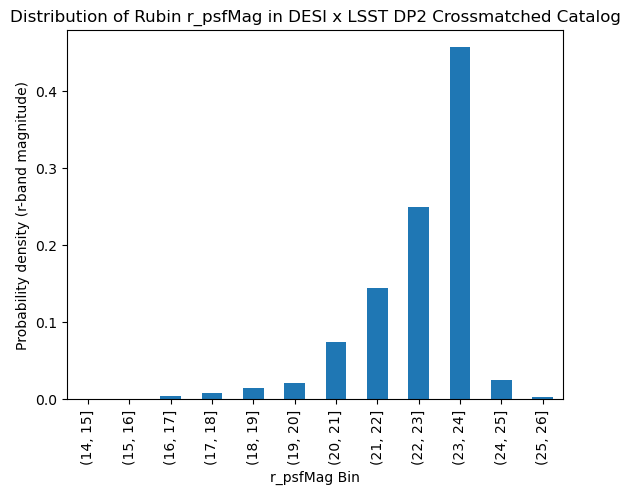

In [32]:
# Plot the histogram of the binned data, normalized to show the probability density.

total_histogram = result.groupby("binned", observed=True).sum()
(total_histogram / total_histogram.sum()).plot(kind="bar")

plt.title("Distribution of Rubin r_psfMag in DESI x LSST DP2 Crossmatched Catalog")
plt.xlabel("r_psfMag Bin")
plt.ylabel("Probability density (r-band magnitude)")
plt.legend().set_visible(False)

plt.show()